# Phase 3+4: K-Fold Out-of-Fold + Meta-Learner

**Giai đoạn 3**: Huấn luyện 3 base models (CNN+LSTM, TL-BiLSTM, Transformer) bằng 5-Fold OOF  
**Giai đoạn 4**: Huấn luyện Meta-Learner trên OOF predictions  

**Pipeline**: Raw Data → Feature Aligner (Phase 1) → 3 Base Models (Phase 2) → OOF Predictions → Meta-Learner → Final 5-class classification

**Output**: Benign, BruteForce, DDoS, DoS, Infiltration

In [1]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from feature_alignment import (
    prepare_combined_dataset, FeatureAligner, create_dataloaders,
    TimeSeriesDataset,
    DEVICE, LATENT_DIM, WINDOW_SIZE, NUM_CLASSES, UNIFIED_CLASSES
)

print(f"Device: {DEVICE}")


Device: cuda


## 1. Load Data & Define Base Models

In [2]:
# Load combined dataset
data = prepare_combined_dataset()

uq_windows = data['uq']['windows']     # (N_uq, 30, 47)
uq_labels = data['uq']['labels']       # (N_uq,)
cic_windows = data['cic']['windows']    # (N_cic, 30, 78)
cic_labels = data['cic']['labels']      # (N_cic,)

uq_n_feat = data['uq']['n_features']   # 47
cic_n_feat = data['cic']['n_features']  # 78

print(f"UQ: {uq_windows.shape}, CIC: {cic_windows.shape}")
print(f"Classes: {data['classes']}")


[UQ] Loaded 1388150 flows, 47 features
[UQ] Label distribution:
Label
Benign          399999
DoS             300000
DDoS            300000
BruteForce      199999
Infiltration    188152
[UQ] Created 186005 windows of shape (186005, 30, 47)
[UQ] Feature dim: 47, Latent target: 64
[CIC] Loaded 237618 flows, 78 features
[CIC] Label distribution:
Label
Benign          100000
DoS              71588
DDoS             50000
BruteForce       15994
Infiltration        36
[CIC] Created 101615 windows of shape (101615, 30, 78)
[CIC] Feature dim: 78, Latent target: 64

=== Combined Dataset ===
UQ: 186005 windows, 47 features
CIC: 101615 windows, 78 features
Total: 287620 windows
UQ: (186005, 30, 47), CIC: (101615, 30, 78)
Classes: ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Infiltration']


In [3]:
# ================================================================
# Define 3 Base Models (same architectures as Phase 2 notebooks)
# ================================================================

# --- Model 1: CNN + LSTM ---
class CNN_LSTM(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(latent_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(128, num_classes))

    def forward(self, z):
        x = z.permute(0, 2, 1)
        x = self.cnn(x).permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        return self.classifier(h_n[-1])


# --- Model 2: TL-BiLSTM ---
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, lstm_output):
        attn_weights = torch.softmax(self.attention(lstm_output), dim=1)
        return (lstm_output * attn_weights).sum(dim=1), attn_weights.squeeze(-1)


class TL_BiLSTM(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=128, num_classes=NUM_CLASSES):
        super().__init__()
        self.bilstm = nn.LSTM(latent_dim, hidden_dim // 2, num_layers=2,
                              batch_first=True, dropout=0.3, bidirectional=True)
        self.attention = TemporalAttention(hidden_dim)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden_dim, num_classes))

    def forward(self, z):
        lstm_out, _ = self.bilstm(z)
        context, _ = self.attention(lstm_out)
        return self.classifier(self.layer_norm(context))


# --- Model 3: Transformer ---
class TransformerClassifier(nn.Module):
    def __init__(self, d_model=LATENT_DIM, nhead=8, num_layers=4,
                 dim_feedforward=256, num_classes=NUM_CLASSES):
        super().__init__()
        self.pos_enc = nn.Parameter(torch.randn(1, WINDOW_SIZE, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(d_model, num_classes))

    def forward(self, z):
        x = z + self.pos_enc[:, :z.size(1), :]
        x = self.layer_norm(self.transformer(x))
        return self.classifier(x.mean(dim=1))


# --- Wrapper: FeatureAligner + BaseModel ---
class AlignerWithModel(nn.Module):
    def __init__(self, uq_dim, cic_dim, base_model):
        super().__init__()
        self.aligner = FeatureAligner(uq_dim, cic_dim)
        self.base_model = base_model

    def forward(self, x, dataset_type='uq'):
        z = self.aligner(x, dataset_type)
        return self.base_model(z)

    def predict_proba(self, x, dataset_type='uq'):
        return torch.softmax(self.forward(x, dataset_type), dim=1)


# Factory to create fresh models
def create_models(uq_dim, cic_dim):
    return {
        'cnn_lstm': AlignerWithModel(uq_dim, cic_dim, CNN_LSTM()),
        'tl_bilstm': AlignerWithModel(uq_dim, cic_dim, TL_BiLSTM()),
        'transformer': AlignerWithModel(uq_dim, cic_dim, TransformerClassifier()),
    }

# Test
models = create_models(uq_n_feat, cic_n_feat)
for name, m in models.items():
    params = sum(p.numel() for p in m.parameters())
    print(f"{name}: {params:,} params")


cnn_lstm: 364,869 params
tl_bilstm: 208,646 params
transformer: 235,845 params


## 2. Training Utilities

In [4]:
from torch.utils.data import DataLoader

BATCH_SIZE = 256
BASE_EPOCHS = 30
PATIENCE = 5


def train_base_model(model, uq_train_X, uq_train_y, cic_train_X, cic_train_y,
                     uq_val_X, uq_val_y, cic_val_X, cic_val_y,
                     epochs=BASE_EPOCHS, lr=1e-3):
    """Train a single base model on UQ + CIC data with early stopping."""
    model = model.to(DEVICE)

    # Class weights
    all_y = np.concatenate([uq_train_y, cic_train_y])
    cc = np.bincount(all_y, minlength=NUM_CLASSES)
    cw = 1.0 / (cc + 1e-6)
    cw = cw / cw.sum() * NUM_CLASSES
    criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(cw).to(DEVICE))

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    # DataLoaders
    uq_train_loader = create_dataloaders(uq_train_X, uq_train_y, 'uq', BATCH_SIZE, True)
    cic_train_loader = create_dataloaders(cic_train_X, cic_train_y, 'cic', BATCH_SIZE, True)
    uq_val_loader = create_dataloaders(uq_val_X, uq_val_y, 'uq', BATCH_SIZE, False)
    cic_val_loader = create_dataloaders(cic_val_X, cic_val_y, 'cic', BATCH_SIZE, False)

    best_val_loss = float('inf')
    best_state = None
    patience_ctr = 0

    for epoch in range(epochs):
        # Train
        model.train()
        uq_it, cic_it = iter(uq_train_loader), iter(cic_train_loader)
        train_loss, n = 0, 0
        while True:
            done = True
            for it_ref, dtype in [('uq', 'uq'), ('cic', 'cic')]:
                it = uq_it if dtype == 'uq' else cic_it
                if it is None:
                    continue
                try:
                    x, y, _ = next(it)
                    done = False
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    optimizer.zero_grad()
                    loss = criterion(model(x, dtype), y)
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    train_loss += loss.item() * len(y)
                    n += len(y)
                except StopIteration:
                    if dtype == 'uq':
                        uq_it = None
                    else:
                        cic_it = None
            if done or (uq_it is None and cic_it is None):
                break

        # Validate
        model.eval()
        val_loss, vn = 0, 0
        with torch.no_grad():
            for loader, dtype in [(uq_val_loader, 'uq'), (cic_val_loader, 'cic')]:
                for x, y, _ in loader:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    loss = criterion(model(x, dtype), y)
                    val_loss += loss.item() * len(y)
                    vn += len(y)

        val_loss /= vn
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss


@torch.no_grad()
def predict_proba_dataset(model, windows, dataset_type, batch_size=512):
    """Get softmax probabilities for a dataset."""
    model.eval()
    ds = TimeSeriesDataset(windows, np.zeros(len(windows)), dataset_type)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    all_probs = []
    for x, _, _ in loader:
        x = x.to(DEVICE)
        probs = torch.softmax(model(x, dataset_type), dim=1)
        all_probs.append(probs.cpu().numpy())
    return np.vstack(all_probs)


print("Training utilities defined.")


Training utilities defined.


## 3. K-Fold Out-of-Fold Predictions (Phase 3)

Huấn luyện mỗi base model 5 lần (K=5 folds). Mỗi lần lấy 4 folds để train, dự đoán fold còn lại.  
Sau 5 vòng, mỗi sample đều có prediction từ model **chưa từng nhìn thấy** dữ liệu đó → tránh học vẹt.

**Lưu ý**: UQ và CIC có feature dims khác nhau nên phải handle riêng trong mỗi fold.

In [5]:
K = 4
MODEL_NAMES = ['cnn_lstm', 'tl_bilstm', 'transformer']

# We need a unified index for K-Fold across both datasets
# Strategy: separate K-Fold for UQ and CIC, then combine OOF predictions

# Initialize OOF arrays
uq_oof = {name: np.zeros((len(uq_labels), NUM_CLASSES)) for name in MODEL_NAMES}
cic_oof = {name: np.zeros((len(cic_labels), NUM_CLASSES)) for name in MODEL_NAMES}

skf_uq = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
skf_cic = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

# Generate fold indices
uq_folds = list(skf_uq.split(uq_windows, uq_labels))
cic_folds = list(skf_cic.split(cic_windows, cic_labels))

print(f"K-Fold OOF: {K} folds, {len(MODEL_NAMES)} models")
print(f"UQ: {len(uq_labels)} samples, CIC: {len(cic_labels)} samples")
print(f"Total training runs: {K} folds × {len(MODEL_NAMES)} models = {K * len(MODEL_NAMES)}")


K-Fold OOF: 4 folds, 3 models
UQ: 186005 samples, CIC: 101615 samples
Total training runs: 4 folds × 3 models = 12


In [6]:
%%time
# === K-Fold OOF Loop ===

for fold_idx in range(K):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}/{K}")
    print(f"{'='*60}")

    # Get fold indices
    uq_train_idx, uq_val_idx = uq_folds[fold_idx]
    cic_train_idx, cic_val_idx = cic_folds[fold_idx]

    # Split data for this fold
    uq_train_X, uq_val_X = uq_windows[uq_train_idx], uq_windows[uq_val_idx]
    uq_train_y, uq_val_y = uq_labels[uq_train_idx], uq_labels[uq_val_idx]
    cic_train_X, cic_val_X = cic_windows[cic_train_idx], cic_windows[cic_val_idx]
    cic_train_y, cic_val_y = cic_labels[cic_train_idx], cic_labels[cic_val_idx]

    print(f"UQ  train: {len(uq_train_X)}, val: {len(uq_val_X)}")
    print(f"CIC train: {len(cic_train_X)}, val: {len(cic_val_X)}")

    # Train each base model
    for model_name in MODEL_NAMES:
        print(f"\n--- Training {model_name} (Fold {fold_idx+1}) ---")

        # Create fresh model
        models = create_models(uq_n_feat, cic_n_feat)
        model = models[model_name]

        # Train
        model, best_loss = train_base_model(
            model,
            uq_train_X, uq_train_y, cic_train_X, cic_train_y,
            uq_val_X, uq_val_y, cic_val_X, cic_val_y,
            epochs=BASE_EPOCHS
        )
        print(f"  Best val loss: {best_loss:.4f}")

        # Predict OOF probabilities on validation fold
        uq_probs = predict_proba_dataset(model, uq_val_X, 'uq')
        cic_probs = predict_proba_dataset(model, cic_val_X, 'cic')

        # Store OOF predictions
        uq_oof[model_name][uq_val_idx] = uq_probs
        cic_oof[model_name][cic_val_idx] = cic_probs

        # Quick accuracy check
        uq_acc = (uq_probs.argmax(1) == uq_val_y).mean()
        cic_acc = (cic_probs.argmax(1) == cic_val_y).mean()
        print(f"  OOF Acc — UQ: {uq_acc:.4f}, CIC: {cic_acc:.4f}")

        # Free GPU memory
        del model, models
        torch.cuda.empty_cache()

print(f"\n{'='*60}")
print("K-Fold OOF complete!")
print(f"{'='*60}")



FOLD 1/4
UQ  train: 139503, val: 46502
CIC train: 76211, val: 25404

--- Training cnn_lstm (Fold 1) ---
  Best val loss: 0.1534
  OOF Acc — UQ: 0.9295, CIC: 0.9652

--- Training tl_bilstm (Fold 1) ---
  Best val loss: 0.0773
  OOF Acc — UQ: 0.9277, CIC: 0.9967

--- Training transformer (Fold 1) ---
  Best val loss: 0.0740
  OOF Acc — UQ: 0.9353, CIC: 0.9970

FOLD 2/4
UQ  train: 139504, val: 46501
CIC train: 76211, val: 25404

--- Training cnn_lstm (Fold 2) ---
  Best val loss: 0.1662
  OOF Acc — UQ: 0.9288, CIC: 0.9838

--- Training tl_bilstm (Fold 2) ---
  Best val loss: 0.0775
  OOF Acc — UQ: 0.9342, CIC: 0.9961

--- Training transformer (Fold 2) ---
  Best val loss: 0.0747
  OOF Acc — UQ: 0.9309, CIC: 0.9975

FOLD 3/4
UQ  train: 139504, val: 46501
CIC train: 76211, val: 25404

--- Training cnn_lstm (Fold 3) ---
  Best val loss: 0.1351
  OOF Acc — UQ: 0.9342, CIC: 0.9896

--- Training tl_bilstm (Fold 3) ---
  Best val loss: 0.0761
  OOF Acc — UQ: 0.9393, CIC: 0.9970

--- Training tr

In [7]:
# === Assemble Meta-Dataset ===
# Concatenate UQ and CIC OOF predictions
# X_meta = [oof_cnn_lstm(5) | oof_bilstm(5) | oof_transformer(5)] = (N_total, 15)

# Stack OOF predictions: (N, 5) per model
uq_meta_parts = [uq_oof[name] for name in MODEL_NAMES]
cic_meta_parts = [cic_oof[name] for name in MODEL_NAMES]

# Concatenate horizontally: (N, 15)
uq_X_meta = np.hstack(uq_meta_parts)
cic_X_meta = np.hstack(cic_meta_parts)

# Combine UQ and CIC
X_meta = np.vstack([uq_X_meta, cic_X_meta])
y_meta = np.concatenate([uq_labels, cic_labels])

# Track origin
dataset_origin = np.array(['uq'] * len(uq_labels) + ['cic'] * len(cic_labels))

print(f"Meta-Dataset: X_meta {X_meta.shape}, y_meta {y_meta.shape}")
print(f"Feature breakdown: {len(MODEL_NAMES)} models × {NUM_CLASSES} classes = {X_meta.shape[1]} features")
print(f"\nPer-model OOF accuracy:")
for i, name in enumerate(MODEL_NAMES):
    preds = X_meta[:, i*NUM_CLASSES:(i+1)*NUM_CLASSES].argmax(1)
    acc = (preds == y_meta).mean()
    f1 = f1_score(y_meta, preds, average='weighted')
    print(f"  {name}: Acc={acc:.4f}, Weighted-F1={f1:.4f}")

# Save meta-dataset
os.makedirs('../Project/Model/Model_2017', exist_ok=True)
np.savez('../Project/Model/Model_2017/meta_dataset.npz',
         X_meta=X_meta, y_meta=y_meta, dataset_origin=dataset_origin)
print("\nMeta-dataset saved.")


Meta-Dataset: X_meta (287620, 15), y_meta (287620,)
Feature breakdown: 3 models × 5 classes = 15 features

Per-model OOF accuracy:
  cnn_lstm: Acc=0.9487, Weighted-F1=0.9501
  tl_bilstm: Acc=0.9558, Weighted-F1=0.9576
  transformer: Acc=0.9561, Weighted-F1=0.9579

Meta-dataset saved.


## 4. Train Meta-Learner (Phase 4)

Vứt bỏ hoàn toàn dữ liệu mạng gốc (47/78 đặc trưng) và không gian ẩn 64 chiều.  
Meta-Learner chỉ nhận `X_meta (N, 15)` — OOF predictions từ 3 base models.

**Hai phương pháp:**
- **Option A**: Logistic Regression (sklearn) — nhanh, stable
- **Option B**: 1-layer Dense NN (Linear(15, 5) + Softmax) — có thể learn nonlinear weights

In [8]:
from sklearn.model_selection import train_test_split
import joblib

# Split meta-dataset: 80% train, 20% test (stratified)
X_train_meta, X_test_meta, y_train_meta, y_test_meta, origin_train, origin_test = \
    train_test_split(X_meta, y_meta, dataset_origin,
                     test_size=0.2, random_state=42, stratify=y_meta)

print(f"Meta Train: {X_train_meta.shape}, Meta Test: {X_test_meta.shape}")

# ================================================================
# Option A: Logistic Regression Meta-Learner
# ================================================================
print("\n=== Option A: Logistic Regression ===\n")

lr_meta = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    C=1.0,
    max_iter=1000,
    random_state=42,
)
lr_meta.fit(X_train_meta, y_train_meta)

lr_preds = lr_meta.predict(X_test_meta)
lr_f1 = f1_score(y_test_meta, lr_preds, average='weighted')
print(f"Logistic Regression weighted F1: {lr_f1:.4f}")
print(classification_report(y_test_meta, lr_preds,
                            target_names=UNIFIED_CLASSES, digits=4))

# ================================================================
# Option B: 1-Layer Dense NN Meta-Learner
# ================================================================
print("\n=== Option B: Dense NN (1 layer) ===\n")


class DenseMetaLearner(nn.Module):
    def __init__(self, input_dim=15, num_classes=NUM_CLASSES):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


dense_meta = DenseMetaLearner(X_meta.shape[1]).to(DEVICE)
meta_criterion = nn.CrossEntropyLoss()
meta_optimizer = optim.Adam(dense_meta.parameters(), lr=1e-2)

# Train Dense NN
X_train_t = torch.FloatTensor(X_train_meta).to(DEVICE)
y_train_t = torch.LongTensor(y_train_meta).to(DEVICE)
X_test_t = torch.FloatTensor(X_test_meta).to(DEVICE)

for epoch in range(200):
    dense_meta.train()
    meta_optimizer.zero_grad()
    logits = dense_meta(X_train_t)
    loss = meta_criterion(logits, y_train_t)
    loss.backward()
    meta_optimizer.step()

dense_meta.eval()
with torch.no_grad():
    nn_preds = dense_meta(X_test_t).argmax(1).cpu().numpy()

nn_f1 = f1_score(y_test_meta, nn_preds, average='weighted')
print(f"Dense NN weighted F1: {nn_f1:.4f}")
print(classification_report(y_test_meta, nn_preds,
                            target_names=UNIFIED_CLASSES, digits=4))

# ================================================================
# Select best Meta-Learner
# ================================================================
if lr_f1 >= nn_f1:
    print(f"\n✓ Best Meta-Learner: Logistic Regression (F1={lr_f1:.4f})")
    best_meta = 'logistic_regression'
    final_preds = lr_preds
    joblib.dump(lr_meta, '../Project/Model/Model_2017/meta_learner_lr.pkl')
else:
    print(f"\n✓ Best Meta-Learner: Dense NN (F1={nn_f1:.4f})")
    best_meta = 'dense_nn'
    final_preds = nn_preds
    torch.save(dense_meta.state_dict(), '../Project/Model/Model_2017/meta_learner_nn.pth')

print(f"Meta-Learner saved.")


Meta Train: (230096, 15), Meta Test: (57524, 15)

=== Option A: Logistic Regression ===

Logistic Regression weighted F1: 0.9723
              precision    recall  f1-score   support

      Benign     0.9812    0.9773    0.9792     32254
  BruteForce     0.9633    0.9919    0.9774      6660
        DDoS     0.9977    0.9992    0.9985      7736
         DoS     0.9933    0.9559    0.9743      4948
Infiltration     0.8856    0.9015    0.8935      5926

    accuracy                         0.9723     57524
   macro avg     0.9642    0.9652    0.9646     57524
weighted avg     0.9725    0.9723    0.9723     57524


=== Option B: Dense NN (1 layer) ===

Dense NN weighted F1: 0.9721
              precision    recall  f1-score   support

      Benign     0.9810    0.9774    0.9792     32254
  BruteForce     0.9640    0.9920    0.9778      6660
        DDoS     0.9970    0.9991    0.9981      7736
         DoS     0.9922    0.9553    0.9734      4948
Infiltration     0.8852    0.8993    0.8922

## 5. Final Evaluation & Visualization

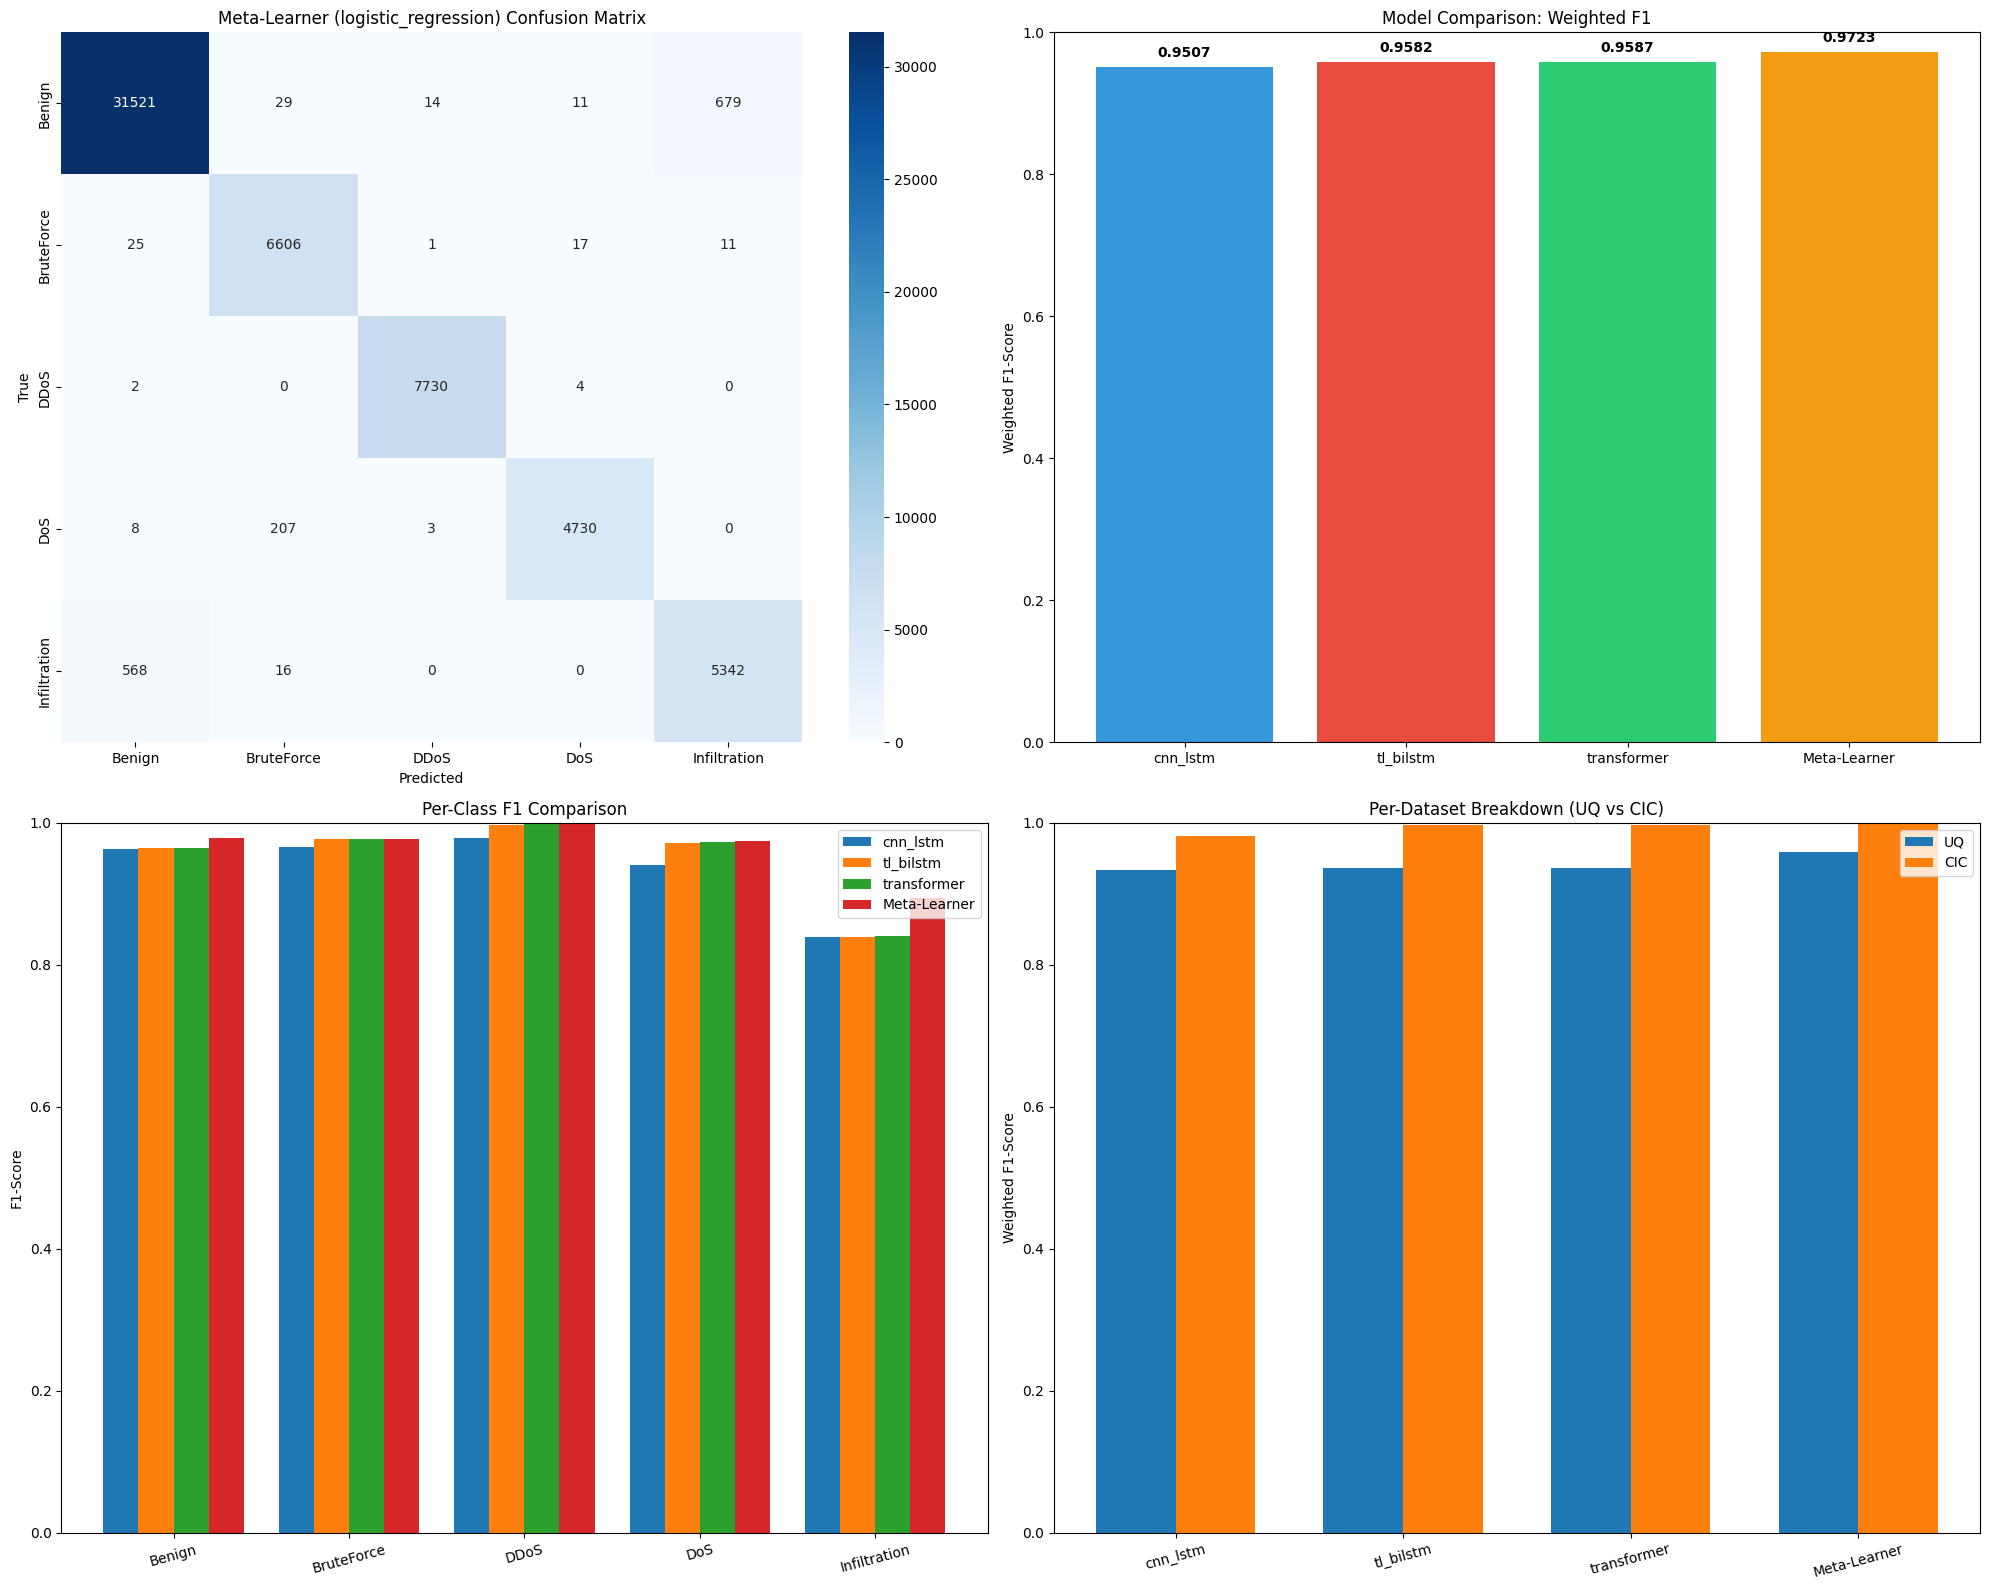


=== FINAL SUMMARY ===
Best Meta-Learner: logistic_regression
Meta-Learner F1: 0.9723
vs Best Base Model: 0.9587 (transformer)
Improvement: +0.0136


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# --- 1. Meta-Learner Confusion Matrix ---
cm = confusion_matrix(y_test_meta, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=UNIFIED_CLASSES, yticklabels=UNIFIED_CLASSES, ax=axes[0, 0])
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('True')
axes[0, 0].set_title(f'Meta-Learner ({best_meta}) Confusion Matrix')

# --- 2. Per-model vs Meta-Learner F1 comparison ---
f1_scores = {}
for i, name in enumerate(MODEL_NAMES):
    preds_i = X_test_meta[:, i*NUM_CLASSES:(i+1)*NUM_CLASSES].argmax(1)
    f1_scores[name] = f1_score(y_test_meta, preds_i, average='weighted')
f1_scores['Meta-Learner'] = f1_score(y_test_meta, final_preds, average='weighted')

bars = axes[0, 1].bar(f1_scores.keys(), f1_scores.values(), color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0, 1].set_ylabel('Weighted F1-Score')
axes[0, 1].set_title('Model Comparison: Weighted F1')
axes[0, 1].set_ylim([0, 1])
for bar, val in zip(bars, f1_scores.values()):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# --- 3. Per-class F1 comparison ---
from sklearn.metrics import f1_score as f1_func

per_class_f1 = {}
for i, name in enumerate(MODEL_NAMES):
    preds_i = X_test_meta[:, i*NUM_CLASSES:(i+1)*NUM_CLASSES].argmax(1)
    per_class_f1[name] = f1_func(y_test_meta, preds_i, average=None,
                                  labels=range(NUM_CLASSES))
per_class_f1['Meta-Learner'] = f1_func(y_test_meta, final_preds, average=None,
                                        labels=range(NUM_CLASSES))

x_pos = np.arange(NUM_CLASSES)
width = 0.2
for j, (name, f1s) in enumerate(per_class_f1.items()):
    axes[1, 0].bar(x_pos + j*width, f1s, width, label=name)
axes[1, 0].set_xticks(x_pos + width*1.5)
axes[1, 0].set_xticklabels(UNIFIED_CLASSES, rotation=15)
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('Per-Class F1 Comparison')
axes[1, 0].legend()
axes[1, 0].set_ylim([0, 1])

# --- 4. Per-dataset breakdown (UQ vs CIC) ---
uq_mask = origin_test == 'uq'
cic_mask = origin_test == 'cic'

dataset_f1 = {}
for label, mask in [('UQ', uq_mask), ('CIC', cic_mask)]:
    if mask.sum() > 0:
        dataset_f1[label] = {}
        for i, name in enumerate(MODEL_NAMES):
            preds_i = X_test_meta[mask, i*NUM_CLASSES:(i+1)*NUM_CLASSES].argmax(1)
            dataset_f1[label][name] = f1_score(y_test_meta[mask], preds_i, average='weighted')
        dataset_f1[label]['Meta-Learner'] = f1_score(y_test_meta[mask], final_preds[mask],
                                                      average='weighted')

x_pos = np.arange(len(MODEL_NAMES) + 1)
width = 0.35
for j, (ds_name, scores) in enumerate(dataset_f1.items()):
    vals = [scores[n] for n in MODEL_NAMES] + [scores['Meta-Learner']]
    axes[1, 1].bar(x_pos + j*width, vals, width, label=ds_name)
axes[1, 1].set_xticks(x_pos + width/2)
axes[1, 1].set_xticklabels(MODEL_NAMES + ['Meta-Learner'], rotation=15)
axes[1, 1].set_ylabel('Weighted F1-Score')
axes[1, 1].set_title('Per-Dataset Breakdown (UQ vs CIC)')
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('../Project/Model/Model_2017/meta_learner_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== FINAL SUMMARY ===")
print(f"Best Meta-Learner: {best_meta}")
print(f"Meta-Learner F1: {f1_scores['Meta-Learner']:.4f}")
print(f"vs Best Base Model: {max(f1_scores[n] for n in MODEL_NAMES):.4f} "
      f"({max(MODEL_NAMES, key=lambda n: f1_scores[n])})")
improvement = f1_scores['Meta-Learner'] - max(f1_scores[n] for n in MODEL_NAMES)
print(f"Improvement: {improvement:+.4f}")


## 6. Inference Pipeline

Tạo pipeline hoàn chỉnh: Raw Data → FeatureAligner → 3 Base Models → Meta-Learner → Final Prediction

In [10]:
# === Train final base models on ALL data (for inference) ===
print("Training final base models on full dataset...")

final_models = {}
for model_name in MODEL_NAMES:
    print(f"\nTraining final {model_name}...")
    models = create_models(uq_n_feat, cic_n_feat)
    model = models[model_name]

    # Use 90% train, 10% val from full dataset
    from sklearn.model_selection import train_test_split as tts
    uq_tr, uq_vl, uq_yr, uq_yv = tts(uq_windows, uq_labels, test_size=0.1,
                                        random_state=42, stratify=uq_labels)
    cic_tr, cic_vl, cic_yr, cic_yv = tts(cic_windows, cic_labels, test_size=0.1,
                                           random_state=42, stratify=cic_labels)

    model, val_loss = train_base_model(
        model, uq_tr, uq_yr, cic_tr, cic_yr,
        uq_vl, uq_yv, cic_vl, cic_yv,
        epochs=BASE_EPOCHS
    )
    print(f"  Final {model_name} val loss: {val_loss:.4f}")

    # Save
    torch.save(model.state_dict(),
               f'../Project/Model/Model_2017/final_{model_name}.pth')
    final_models[model_name] = model
    torch.cuda.empty_cache()

print("\n✓ All final models saved.")


# === Inference function ===
def predict(windows, dataset_type, final_models, meta_learner, meta_type='lr'):
    """
    Full inference pipeline.

    Args:
        windows: np.ndarray (N, 30, feature_dim) — raw scaled features
        dataset_type: 'uq' or 'cic'
        final_models: dict of trained base models
        meta_learner: trained meta-learner (sklearn or pytorch)
        meta_type: 'lr' for LogisticRegression, 'nn' for Dense NN

    Returns:
        predictions: np.ndarray (N,) — class indices
        class_names: list of predicted class names
    """
    # Get base model probabilities
    probs_list = []
    for name in MODEL_NAMES:
        probs = predict_proba_dataset(final_models[name], windows, dataset_type)
        probs_list.append(probs)

    # Stack to create X_meta
    X_meta_new = np.hstack(probs_list)  # (N, 15)

    # Meta-learner prediction
    if meta_type == 'lr':
        preds = meta_learner.predict(X_meta_new)
    else:
        with torch.no_grad():
            logits = meta_learner(torch.FloatTensor(X_meta_new).to(DEVICE))
            preds = logits.argmax(1).cpu().numpy()

    class_names = [UNIFIED_CLASSES[p] for p in preds]
    return preds, class_names


# Quick test
print("\n=== Quick Inference Test ===")
test_windows = uq_windows[:10]
meta = lr_meta if best_meta == 'logistic_regression' else dense_meta
meta_t = 'lr' if best_meta == 'logistic_regression' else 'nn'
preds, names = predict(test_windows, 'uq', final_models, meta, meta_t)
print(f"Predictions: {names}")
print(f"True labels: {[UNIFIED_CLASSES[l] for l in uq_labels[:10]]}")


Training final base models on full dataset...

Training final cnn_lstm...
  Final cnn_lstm val loss: 0.0870

Training final tl_bilstm...
  Final tl_bilstm val loss: 0.0708

Training final transformer...
  Final transformer val loss: 0.0677

✓ All final models saved.

=== Quick Inference Test ===
Predictions: ['Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign']
True labels: ['Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign']
